# Analytics
This notebook contains an analysis of the training data.
The included functions are:
- `exercise_e1rm_prog`, to plot the how the maximum estimated one-rep max for a given exercise changes over time.
- `plot_weekly_volume`, to plot the total weekly 'tonnage' - a measure of training volume - and how it changes over time.

In [1]:
import sys
sys.path.append("../src")
from data_ETL_functions import *

data_dir = "../data/synthetic/mock_"

weight_df = load_weight(file=f"{data_dir}cronometer_weight.csv")
sleep_df = load_sleep(file=f"{data_dir}cronometer_sleep.csv")
hr_df = load_hr(file=f"{data_dir}cronometer_heartrate.csv")
food_df = load_food(file=f"{data_dir}cronometer_food.csv")
bodyfat_df = load_bf(file=f"{data_dir}cronometer_bodyfat.csv")

sessions_df = load_sessions(file=f"{data_dir}training.xlsx")
strength_df = load_strength_log(file=f"{data_dir}training.xlsx")
# carido_df = load_cardio_log(file=f"{data_dir}training.xlsx")      # no features for this yet, do not read in
# mobility_df = load_mobility_log(file=f"{data_dir}training.xlsx")  # no features for this yet, do not read in
exercise_lookup_df = load_exercise_lookup(file=f"{data_dir}training.xlsx")

## Estimated one rep max
The Estimated 1 Rep Max (e1rm) multiplies the weight lifted with number of reps to represent a standardised strength metric where low rep lifts can be compared to high rep lifts. The dataFrame `strength_df` already calculates the e1rm for each set recorded, but it would be interesting to present the e1rm per exercise, or for a single exercise over time.

Now, write the function to do this.
Inputs:
- dataframe (strength_df, exercise_lookup, sessions)
- exercise

Outputs:
- Plot of e1rm for an exercise over time

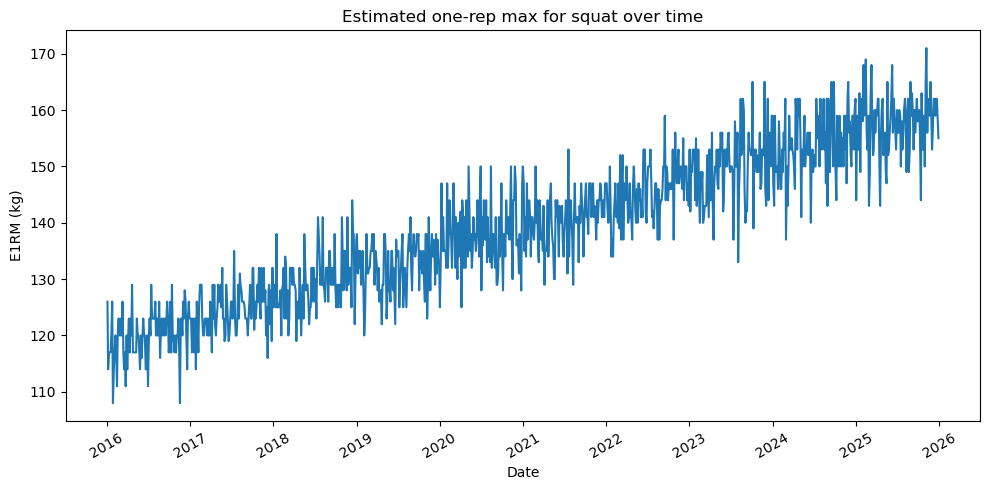

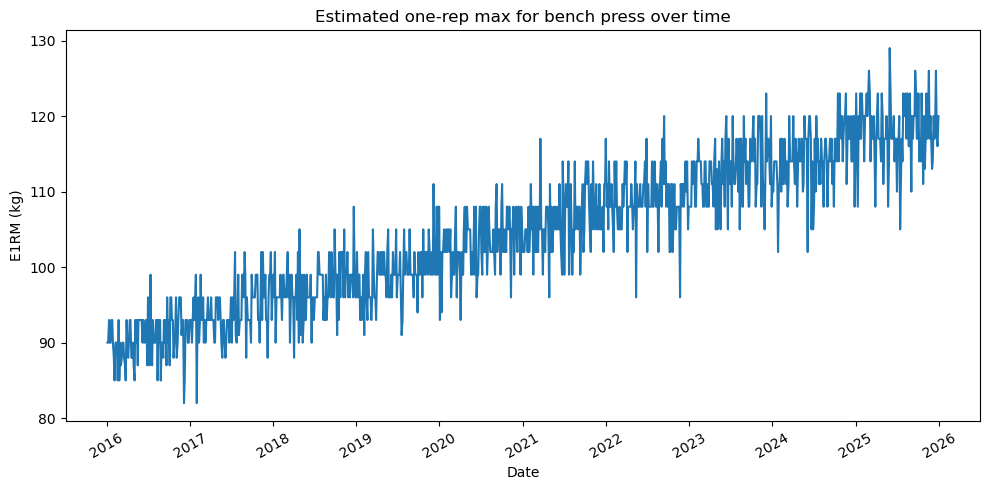

In [2]:
import matplotlib.pyplot as plt

# function to build the analysis_df
def build_analysis_df():
    # Merge tables to get key columns
    analysis_df = (
        strength_df
        .merge(
            sessions_df[["session_id", "date"]],
            on="session_id",
            how="left"
        )
        .merge(
            exercise_lookup_df[["exercise_id", "exercise_name"]],
            on="exercise_id",
            how="left"
        ))

    # Error checks
    if analysis_df.shape[0] != strength_df.shape[0]:
        print("Number of rows changed after merge. Check for duplicate entries in look up tables")

    if analysis_df["date"].isna().sum() != 0:
        print(f"{analysis_df["date"].isna().sum()} rows do not have matching dates!")
        analysis_df.loc[
            analysis_df["date"].isna()
        ]

    if analysis_df["exercise_name"].isna().sum() != 0:
        print(f"{analysis_df["exercise_name"].isna().sum()} rows do not have matching exercise names!")
        print(analysis_df.loc[
            analysis_df["exercise_name"].isna()
        ])

    return analysis_df

# function plot the e1rm over time of a single exercise from the analysis_df
def exercise_e1rm_prog(analysis_df, exercise="squat"):

    # process input string to ensure the right format
    exercise = exercise.strip().lower()
    if exercise not in analysis_df["exercise_name"].unique():
            return print(f"invalid exercise: '{exercise}'")

    # Now filter to just one exercise
    ex_df = analysis_df.loc[
        analysis_df["exercise_name"] == exercise
        ]
    
    # Now aggregate to 1 row per session, where e1rm is the largest
    ex_progression = (
        ex_df
        .groupby("date", as_index=False)["e1rm"]
        .max()
        .sort_values("date")
    )

    plt.figure(figsize=(10,5))
    plt.plot(ex_progression["date"], ex_progression["e1rm"]);
    plt.xlabel(f"Date")
    plt.ylabel(f"E1RM (kg)")
    plt.title(f"Estimated one-rep max for {exercise} over time")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

analysis_df = build_analysis_df()

exercise_e1rm_prog(analysis_df, "squat")
exercise_e1rm_prog(analysis_df, "bench press")

## Plot Weekly Volume
This should return a plot of total 'tonnage' (weight lifted $\times$ reps) over time, aggregated by week. There should also be an optional filter for specific exercises. This provides a proxy for lifting volume.

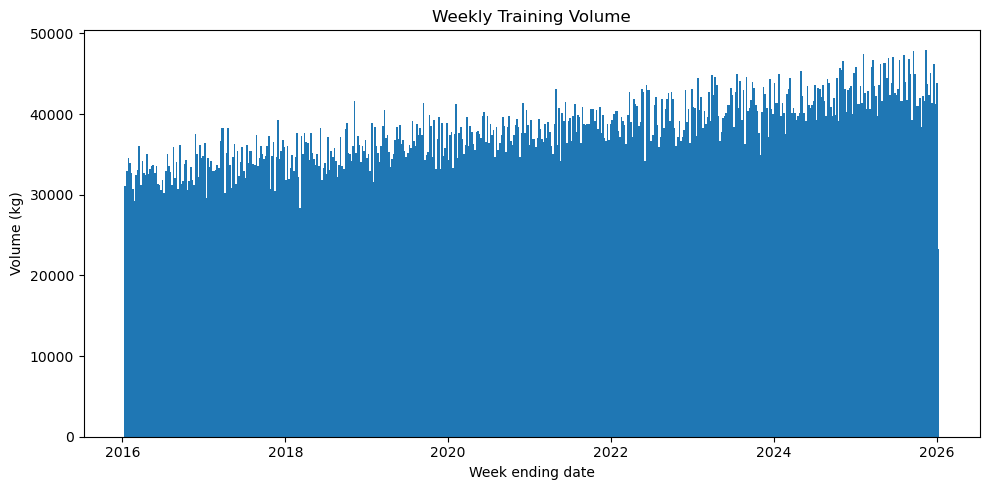

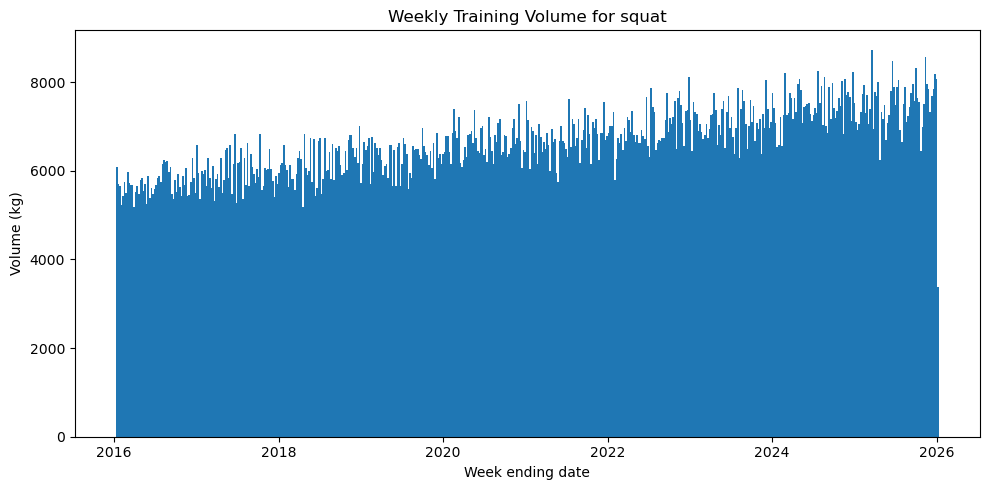

In [3]:
# reuse build_analysis_df function
analysis_df = build_analysis_df()

def plot_weekly_volume(df, exercise=""):
    # check exercise passed
    df = df.copy()

    # process input string to ensure the right format
    exercise = exercise.strip().lower()
    if exercise != "":

        if exercise not in df["exercise_name"].unique():
            return print(f"invalid exercise: '{exercise}'")
        
        df = df.loc[
            df["exercise_name"] == exercise
        ]
    
    # create new "volume" column as a training volume proxy
    df["volume"] = (
        df["load_kg"] *
        df["reps"]
    )

    # Now aggregate to weeks
    weekly_volume = (
        df
        .set_index("date")  # set date as the index
        .resample("W")["volume"]    # group "volume" data into weekly buckets (week ending Sunday)
        .sum()  # aggregate (sum up) all the values for that week.
    )

    plt.figure(figsize=(10,5))
    plt.bar(weekly_volume.index, weekly_volume.values,
            width=7,    # make bar width 7 days wide
            align="edge")    # align the last date, as .resample("W") timestamps the end of the week
    plt.xlabel("Week ending date")
    plt.ylabel("Volume (kg)")
    if exercise != "":
        plt.title(f"Weekly Training Volume for {exercise}")
    else:
        plt.title("Weekly Training Volume")
    plt.tight_layout()
    plt.show()

plot_weekly_volume(df=analysis_df, exercise="")
plot_weekly_volume(df=analysis_df, exercise="squat")